# Notebook 5 – Model Development

Objective

• Build machine learning models to predict customer decline.

• Compare Logistic Regression and Random Forest performance.

• Identify the most important drivers of customer decline.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

retail = pd.read_pickle(
    "/content/drive/MyDrive/Project files/retail_clean.pkl"
)

snapshot_df = pd.read_pickle(
    "/content/drive/MyDrive/Project files/snapshot_df.pkl"
)

snapshot_features = pd.read_pickle(
    "/content/drive/MyDrive/Project files/snapshot_features.pkl"
)

model_df_active = pd.read_pickle(
    "/content/drive/MyDrive/Project files/model_df_active.pkl"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

model_df_active = pd.read_pickle(
    "/content/drive/MyDrive/Project files/model_df_active.pkl"
)

print(model_df_active.shape)
model_df_active.head()

(19480, 23)


,Customer ID,snapshot_date,recency_days,frequency_180d,monetary_180d,aov_180d,previous_spend,recent_spend,spend_trend,previous_orders,...,recent_aov,aov_trend,first_purchase_date,customer_age_days,lifetime_orders,lifetime_spend,future_revenue,current_revenue,revenue_change_pct,decline_label
1,12490,2010-05-31,23.0,6.0,1943.23,323.871667,905.52,1037.71,1.145982,3.0,...,345.903333,1.145982,2009-12-01 12:52:00,180,7,2547.17,509.00,1037.71,-0.509497,1
2,12533,2010-05-31,69.0,1.0,437.97,437.970000,0.00,437.97,1.000000,0.0,...,437.970000,1.000000,2009-12-01 11:50:00,180,2,1367.89,0.00,437.97,-1.000000,1
4,12682,2010-05-31,24.0,9.0,5325.20,591.688889,3178.62,2146.58,0.675318,6.0,...,715.526667,1.350636,2009-12-01 09:28:00,180,10,5751.50,2200.33,2146.58,0.025040,0
5,12758,2010-05-31,31.0,2.0,1970.91,985.455000,0.00,1970.91,1.000000,0.0,...,985.455000,1.000000,2009-12-01 14:40:00,180,3,4425.59,1590.11,1970.91,-0.193210,0
6,12836,2010-05-31,40.0,4.0,1438.44,359.610000,600.35,838.09,1.396002,2.0,...,419.045000,1.396002,2009-12-01 14:19:00,180,5,1862.31,937.45,838.09,0.118555,0


In [ ]:
# ====================================================
# IMPORT LIBRARIES
# ====================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [ ]:
feature_cols = [
    'recency_days',
    'frequency_180d',
    'monetary_180d',
    'aov_180d',
    'previous_spend',
    'spend_trend',
    'previous_orders',
    'recent_orders',
    'frequency_trend',
    'previous_aov',
    'recent_aov',
    'aov_trend',
    'customer_age_days',
    'lifetime_orders',
    'lifetime_spend'
]

X = model_df_active[feature_cols]
y = model_df_active["decline_label"]

In [ ]:
#Step 3 — Train-Test Split
# ====================================================
# TRAIN TEST SPLIT
# ====================================================

# Import train-test split function
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
# stratify=y ensures class balance is maintained
# in both train and test datasets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ====================================================
# AUDIT SPLIT SHAPES
# ====================================================

print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)

print("\ny_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

# ====================================================
# AUDIT CLASS DISTRIBUTION
# ====================================================

print("\nTrain Class Distribution")
print(y_train.value_counts(normalize=True))

print("\nTest Class Distribution")
print(y_test.value_counts(normalize=True))

X_train Shape: (15584, 15)
X_test Shape : (3896, 15)

y_train Shape: (15584,)
y_test Shape : (3896,)

Train Class Distribution
decline_label
1    0.518095
0    0.481905
Name: proportion, dtype: float64

Test Class Distribution
decline_label
1    0.517967
0    0.482033
Name: proportion, dtype: float64


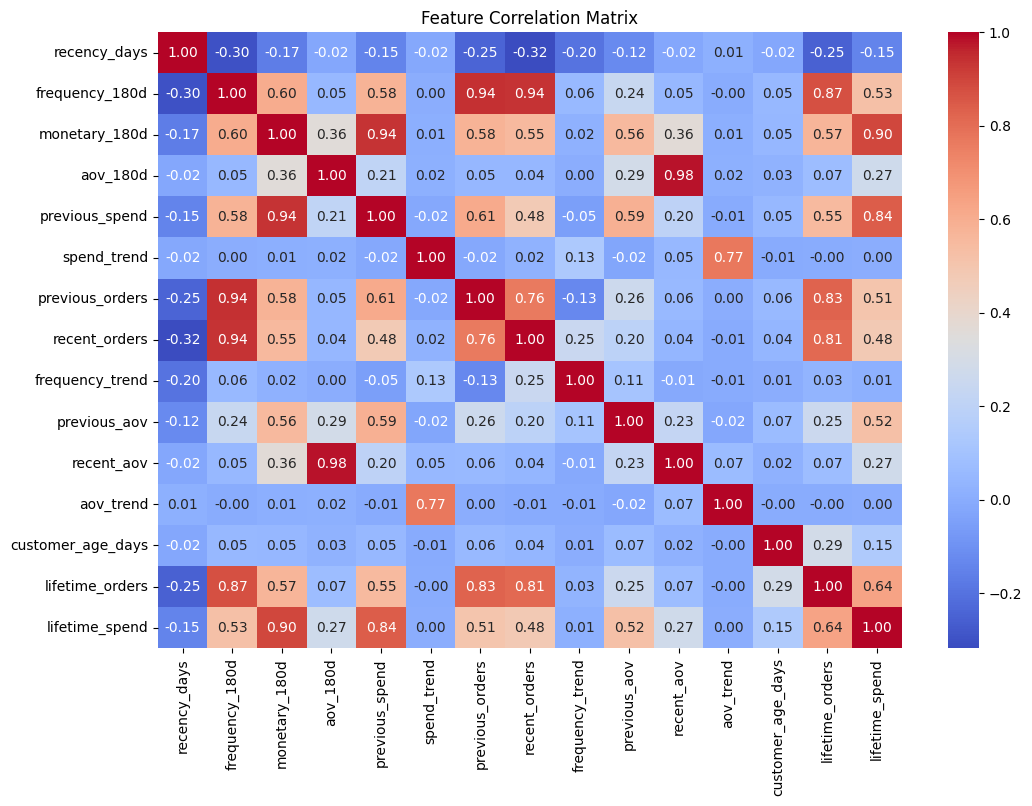

In [ ]:
#Step 4 — Feature Correlation Audit
# ====================================================
# FEATURE CORRELATION AUDIT
# ====================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation matrix
corr_matrix = X.corr()

# Display correlation heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")

plt.show()

In [ ]:
# ====================================================
# IDENTIFY HIGH CORRELATIONS
# ====================================================

corr_pairs = (
    corr_matrix
    .abs()
    .unstack()
    .sort_values(ascending=False)
)

# Remove self-correlations (=1)
corr_pairs = corr_pairs[corr_pairs < 1]

# Show strongest relationships
print(corr_pairs.head(20))

aov_180d         recent_aov         0.981931
recent_aov       aov_180d           0.981931
previous_orders  frequency_180d     0.942753
frequency_180d   previous_orders    0.942753
monetary_180d    previous_spend     0.937160
previous_spend   monetary_180d      0.937160
recent_orders    frequency_180d     0.935236
frequency_180d   recent_orders      0.935236
monetary_180d    lifetime_spend     0.895277
lifetime_spend   monetary_180d      0.895277
lifetime_orders  frequency_180d     0.872806
frequency_180d   lifetime_orders    0.872806
previous_spend   lifetime_spend     0.841059
lifetime_spend   previous_spend     0.841059
lifetime_orders  previous_orders    0.828452
previous_orders  lifetime_orders    0.828452
recent_orders    lifetime_orders    0.810323
lifetime_orders  recent_orders      0.810323
aov_trend        spend_trend        0.772176
spend_trend      aov_trend          0.772176
dtype: float64


Notes For Notebook
Multicollinearity Findings

Highly correlated features were identified.

Most correlations arise because:

Window-based features
share overlapping purchase history

This is expected in snapshot-based customer analytics.

Decision
Keep all 15 features

Reason:

Business meaning retained
No exact duplicates
Tree models handle correlation well
Logistic Regression is only a benchmark model



In [ ]:
#Step 5 — Standardization
# ====================================================
# STANDARDIZE FEATURES
# ====================================================

from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Fit on training data only
# Then transform train and test data

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# ====================================================
# AUDIT SCALED DATA
# ====================================================

print("Training Shape:", X_train_scaled.shape)
print("Testing Shape :", X_test_scaled.shape)

Training Shape: (15584, 15)
Testing Shape : (3896, 15)


In [ ]:
#Step 6 — Train Logistic Regression
# ====================================================
# TRAIN LOGISTIC REGRESSION
# ====================================================

from sklearn.linear_model import LogisticRegression

# Create model

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train model

lr_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression Training Complete")

Logistic Regression Training Complete


In [ ]:
#Step 7 — Generate Predictions
# ====================================================
# GENERATE PREDICTIONS
# ====================================================

# Predicted class

y_pred_lr = lr_model.predict(
    X_test_scaled
)

# Predicted probability

y_prob_lr = lr_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Predictions Generated")

Predictions Generated


In [ ]:
# Step 8 — Evaluate Logistic Regression
# ====================================================
# LOGISTIC REGRESSION EVALUATION
# ====================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ====================================================
# CALCULATE METRICS
# ====================================================

accuracy = accuracy_score(y_test, y_pred_lr)

precision = precision_score(y_test, y_pred_lr)

recall = recall_score(y_test, y_pred_lr)

f1 = f1_score(y_test, y_pred_lr)

roc_auc = roc_auc_score(y_test, y_prob_lr)

# ====================================================
# PRINT RESULTS
# ====================================================

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC AUC  :", round(roc_auc, 4))

# ====================================================
# CONFUSION MATRIX
# ====================================================

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

# ====================================================
# CLASSIFICATION REPORT
# ====================================================

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.6373
Precision: 0.6262
Recall   : 0.7438
F1 Score : 0.68
ROC AUC  : 0.6843

Confusion Matrix
[[ 982  896]
 [ 517 1501]]

Classification Report
              precision    recall  f1-score   support

           0       0.66      0.52      0.58      1878
           1       0.63      0.74      0.68      2018

    accuracy                           0.64      3896
   macro avg       0.64      0.63      0.63      3896
weighted avg       0.64      0.64      0.63      3896



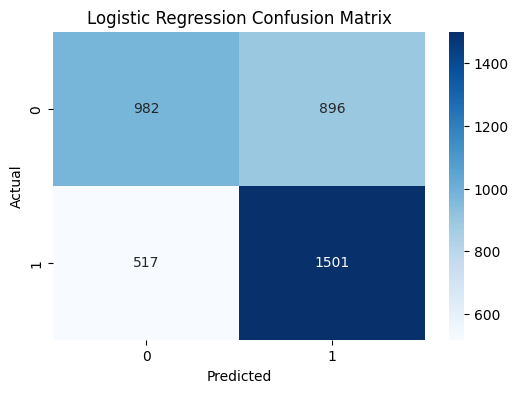

In [ ]:

#Step 9 — Visualize Confusion Matrix
# ====================================================
# CONFUSION MATRIX HEATMAP
# ====================================================

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

Why did Logistic Regression not perform better?
Customer spending behavior is rarely linear. Features such as spend trends, purchase frequency changes, and customer lifetime value often interact in complex ways. Logistic Regression assumes a linear relationship between the features and the target, which limits its ability to capture these behavioral patterns. Therefore, it serves as a useful benchmark, but tree-based models such as Random Forest and XGBoost are expected to perform better by capturing non-linear relationships and feature interactions.


# Why Are We Doing This?

We trained our first machine learning model.

Now we must answer the business question:

> Can Logistic Regression identify customers who are likely to experience a significant decline in spending?

This is our benchmark model.

Every future model (Random Forest, XGBoost) must outperform this baseline.

---

# Logistic Regression Results

| Metric    | Score |
| --------- | ----- |
| Accuracy  | 0.637 |
| Precision | 0.626 |
| Recall    | 0.744 |
| F1 Score  | 0.680 |
| ROC-AUC   | 0.684 |

---

# Business Interpretation

## Recall = 74.4% ⭐

This is the most important metric for your project.

Recall answers:

> Of all customers who actually declined, how many did we successfully identify?

Result:

```text
74.4%
```

Meaning:

Out of 100 declining customers:

```text
74 identified
26 missed
```

From a business perspective:

```text
Good baseline performance
```

The model is catching most declining customers.

---

## Precision = 62.6%

Precision answers:

> When the model predicts decline, how often is it correct?

Result:

```text
62.6%
```

Meaning:

Out of 100 customers flagged:

```text
63 truly decline
37 do not decline
```

Not perfect, but acceptable for an early-warning system.

---

## ROC-AUC = 0.684

Interpretation:

```text
0.50 = Random guessing
0.60 = Weak
0.70 = Reasonable
0.80 = Strong
0.90 = Excellent
```

Your result:

```text
0.684
```

This suggests:

```text
Useful signal exists
but the relationship is not purely linear
```

This is exactly where Random Forest and XGBoost usually help.

---

# Confusion Matrix Interpretation

Actual Results:

|                   | Predicted No Decline | Predicted Decline |
| ----------------- | -------------------- | ----------------- |
| Actual No Decline | 982                  | 896               |
| Actual Decline    | 517                  | 1501              |

---

### True Positives

```text
1501
```

Customers correctly identified as declining.

Excellent.

---

### False Negatives ⭐

```text
517
```

These are the most important errors.

These customers:

```text
Actually declined
BUT
Model failed to identify them
```

Potential lost intervention opportunities.

---

### False Positives

```text
896
```

These customers:

```text
Predicted decline
BUT
Did not decline
```

Not ideal, but less costly than missing a declining customer.

---

# Interview Interpretation

If asked:

> Why did Logistic Regression not perform better?

You can answer:

Customer spending behavior is rarely linear. Features such as spend trends, purchase frequency changes, and customer lifetime value often interact in complex ways. Logistic Regression assumes a linear relationship between the features and the target, which limits its ability to capture these behavioral patterns. Therefore, it serves as a useful benchmark, but tree-based models such as Random Forest and XGBoost are expected to perform better by capturing non-linear relationships and feature interactions.

---

# Notes For Notebook

### Model

```python
LogisticRegression()
```

### Performance

```text
Accuracy = 63.7%
Recall   = 74.4%
F1       = 68.0%
ROC-AUC  = 68.4%
```

### Key Finding

The model successfully identifies most declining customers but generates a substantial number of false positives.

### Business Conclusion

Logistic Regression provides a useful baseline but is unlikely to be the final production model.


In [ ]:
#Step 10 — Train Random Forest
# ====================================================
# RANDOM FOREST CLASSIFIER
# ====================================================

from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(

    # Number of trees
    n_estimators=200,

    # Reproducible results
    random_state=42,

    # Use all CPU cores
    n_jobs=-1
)

# Train model
rf_model.fit(
    X_train,
    y_train
)

print("Random Forest Training Complete")

Random Forest Training Complete


In [ ]:
#Step 11 — Generate Predictions
# ====================================================
# RANDOM FOREST PREDICTIONS
# ====================================================

# Predicted class labels
y_pred_rf = rf_model.predict(
    X_test
)

# Predicted probabilities
y_prob_rf = rf_model.predict_proba(
    X_test
)[:, 1]

print("Predictions Generated")

Predictions Generated


In [ ]:
#Audit
# ====================================================
# PREDICTION AUDIT
# ====================================================

print(y_pred_rf[:10])

print("\n")

print(y_prob_rf[:10])

[1 1 0 0 1 1 0 0 0 0]


[0.96  0.935 0.275 0.18  0.565 0.535 0.3   0.275 0.375 0.23 ]


In [ ]:
# ====================================================
# RANDOM FOREST EVALUATION
# ====================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ====================================================
# CALCULATE METRICS
# ====================================================

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

rf_roc_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

# ====================================================
# PRINT RESULTS
# ====================================================

print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC AUC  :", round(rf_roc_auc, 4))

# ====================================================
# CONFUSION MATRIX
# ====================================================

print("\nConfusion Matrix")
print(
    confusion_matrix(
        y_test,
        y_pred_rf
    )
)

# ====================================================
# CLASSIFICATION REPORT
# ====================================================

print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

Accuracy : 0.6969
Precision: 0.705
Recall   : 0.7131
F1 Score : 0.709
ROC AUC  : 0.7584

Confusion Matrix
[[1276  602]
 [ 579 1439]]

Classification Report
              precision    recall  f1-score   support

           0       0.69      0.68      0.68      1878
           1       0.71      0.71      0.71      2018

    accuracy                           0.70      3896
   macro avg       0.70      0.70      0.70      3896
weighted avg       0.70      0.70      0.70      3896



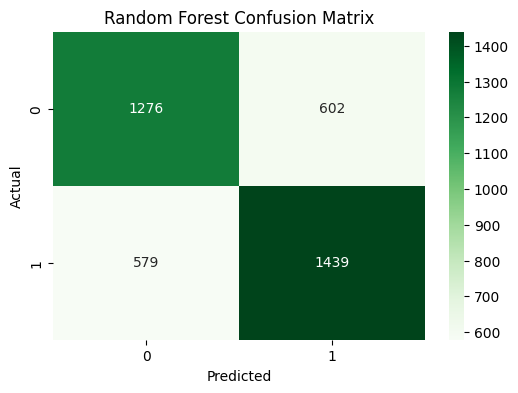

In [ ]:

#Step 13 — Visualize Confusion Matrix
# ====================================================
# RANDOM FOREST CONFUSION MATRIX
# ====================================================

import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Why is Random Forest better than Logistic Regression?
Customer spending behavior is inherently non-linear. Random Forest can capture interactions between features such as recency, spend trends, purchase frequency, and customer lifetime value without assuming a linear relationship. In our project, Random Forest improved ROC-AUC from 0.684 to 0.758 and increased F1 score from 0.680 to 0.709, demonstrating a stronger ability to distinguish declining customers from non-declining customers.


# Why Are We Doing This?

The purpose of Random Forest was to determine whether a non-linear model can capture customer decline behavior better than Logistic Regression.

Now compare both models objectively.

---

# Model Comparison

| Metric    | Logistic Regression | Random Forest | Improvement |
| --------- | ------------------- | ------------- | ----------- |
| Accuracy  | 0.637               | 0.697         | ✅ +0.060    |
| Precision | 0.626               | 0.705         | ✅ +0.079    |
| Recall    | 0.744               | 0.713         | ❌ -0.031    |
| F1 Score  | 0.680               | 0.709         | ✅ +0.029    |
| ROC-AUC   | 0.684               | 0.758         | ✅ +0.074    |

---

# Business Interpretation

## Accuracy

```text
63.7% → 69.7%
```

Improvement:

```text
+6.0 percentage points
```

Random Forest is making more correct predictions overall.

---

## Precision ⭐

```text
62.6% → 70.5%
```

This is a major improvement.

Business meaning:

### Logistic Regression

Out of 100 customers flagged:

```text
63 actually decline
37 false alarms
```

### Random Forest

Out of 100 customers flagged:

```text
71 actually decline
29 false alarms
```

Much better for CRM teams.

---

## Recall ⭐

```text
74.4% → 71.3%
```

Slight decrease.

Meaning:

Random Forest misses slightly more declining customers.

However:

```text
Difference = only 3.1%
```

Not a major drop.

---

## F1 Score

```text
68.0% → 70.9%
```

Improvement.

This means the balance between:

* Precision
* Recall

is better.

---

## ROC-AUC ⭐⭐⭐

```text
68.4% → 75.8%
```

This is the biggest improvement.

Remember:

```text
0.50 = Random
0.60 = Weak
0.70 = Good
0.80 = Strong
```

Random Forest:

```text
0.758
```

This indicates the model is much better at ranking customers from:

```text
Low Risk
↓
High Risk
```

which is exactly what a decline prediction system needs.

---

# Confusion Matrix Interpretation

### Logistic Regression

```text
False Positives = 896
False Negatives = 517
```

### Random Forest

```text
False Positives = 602
False Negatives = 579
```

---

# Key Business Tradeoff

Random Forest:

```text
294 fewer false alarms
```

but

```text
62 additional missed declines
```

This is a very common tradeoff.

The model became more selective.

---

# Interview Interpretation

If asked:

> Why is Random Forest better than Logistic Regression?

You can answer:

Customer spending behavior is inherently non-linear. Random Forest can capture interactions between features such as recency, spend trends, purchase frequency, and customer lifetime value without assuming a linear relationship. In our project, Random Forest improved ROC-AUC from 0.684 to 0.758 and increased F1 score from 0.680 to 0.709, demonstrating a stronger ability to distinguish declining customers from non-declining customers.

---

# Notes For Notebook

### Model

```python
RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
```

### Results

```text
Accuracy : 69.7%
Precision: 70.5%
Recall   : 71.3%
F1 Score : 70.9%
ROC-AUC  : 75.8%
```

### Business Conclusion

Random Forest significantly improves customer decline prediction compared with Logistic Regression.

The strongest improvement is observed in:

```text
Precision
ROC-AUC
```



In [ ]:
#Step 14 — Extract Feature Importance
# ====================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ====================================================

import pandas as pd

# Create feature importance dataframe
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort from highest to lowest importance
feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

# Display results
feature_importance_df

,Feature,Importance
14,lifetime_spend,0.113739
12,customer_age_days,0.109478
2,monetary_180d,0.093481
10,recent_aov,0.093355
0,recency_days,0.091271
3,aov_180d,0.089772
5,spend_trend,0.073986
4,previous_spend,0.070298
9,previous_aov,0.062802
11,aov_trend,0.061534


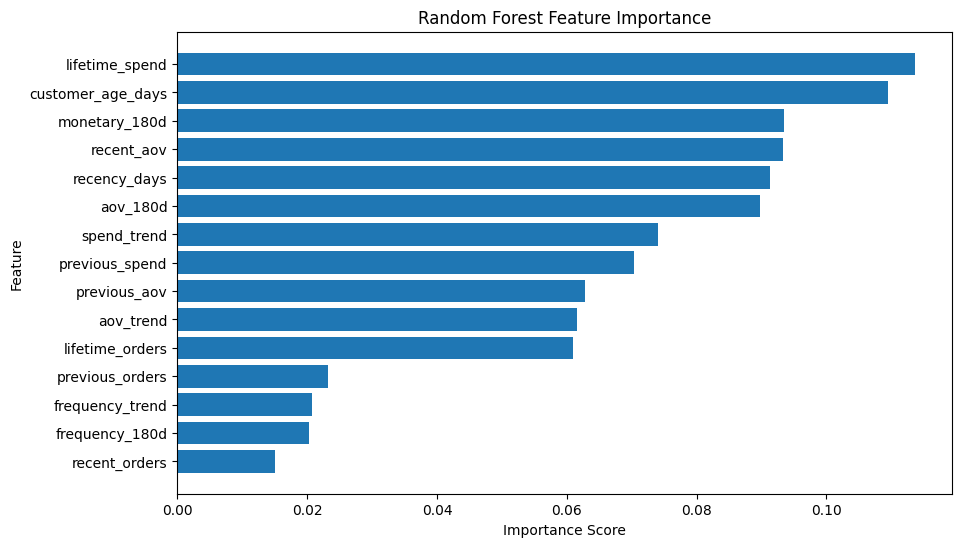

In [ ]:
#Step 15 — Visualize Feature Importance
# ====================================================
# FEATURE IMPORTANCE BAR CHART
# ====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

The Random Forest model showed that customer value and customer maturity were the strongest predictors of future spending decline. Lifetime spend, customer age, monetary value in the previous 180 days, recent average order value, and recency were among the most important features. Interestingly, spend-based features were significantly more predictive than order-count features, suggesting that changes in customer spending behavior provided stronger early warning signals than changes in purchase frequency within the Online Retail II dataset.



In [ ]:
#Step 16 — Calculate Permutation Importance
# ====================================================
# PERMUTATION IMPORTANCE
# ====================================================

from sklearn.inspection import permutation_importance

# Calculate permutation importance
perm_importance = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# ====================================================
# CREATE RESULTS DATAFRAME
# ====================================================

import pandas as pd

permutation_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm_importance.importances_mean
})

# Sort descending
permutation_importance_df = (
    permutation_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

permutation_importance_df

,Feature,Importance
14,lifetime_spend,0.062603
13,lifetime_orders,0.037064
12,customer_age_days,0.031648
2,monetary_180d,0.022408
5,spend_trend,0.017402
3,aov_180d,0.013655
10,recent_aov,0.013321
4,previous_spend,0.012346
11,aov_trend,0.009420
9,previous_aov,0.007983


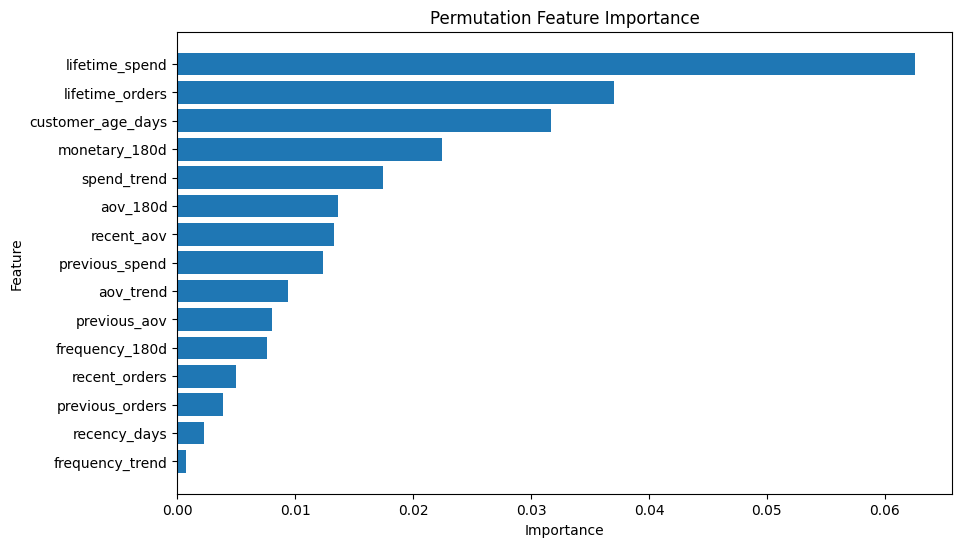

In [ ]:
#Step 17 — Visualize Permutation Importance
# ====================================================
# PERMUTATION IMPORTANCE PLOT
# ====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    permutation_importance_df["Feature"],
    permutation_importance_df["Importance"]
)

plt.title("Permutation Feature Importance")

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
#Train XGBoost
# ====================================================
# XGBOOST CLASSIFIER
# ====================================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Train model
xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost Training Complete")

XGBoost Training Complete


In [ ]:

# ====================================================
# XGBOOST PREDICTIONS
# ====================================================

y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(y_pred_xgb[:10])
print(y_prob_xgb[:10])

[1 1 0 0 0 1 0 0 0 0]
[0.8409064  0.87912565 0.29942274 0.18564688 0.42194518 0.51399356
 0.28899404 0.36491743 0.43626836 0.31971845]


In [ ]:



# ====================================================
# XGBOOST EVALUATION
# ====================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", round(accuracy_score(y_test, y_pred_xgb), 4))
print("Precision:", round(precision_score(y_test, y_pred_xgb), 4))
print("Recall   :", round(recall_score(y_test, y_pred_xgb), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_xgb), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob_xgb), 4))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb))

Accuracy : 0.6702
Precision: 0.6746
Recall   : 0.7017
F1 Score : 0.6879
ROC AUC  : 0.7286

Confusion Matrix
[[1195  683]
 [ 602 1416]]

Classification Report
              precision    recall  f1-score   support

           0       0.66      0.64      0.65      1878
           1       0.67      0.70      0.69      2018

    accuracy                           0.67      3896
   macro avg       0.67      0.67      0.67      3896
weighted avg       0.67      0.67      0.67      3896



In [ ]:
#Step 18 — Hyperparameter Tuning
# ====================================================
# XGBOOST HYPERPARAMETER TUNING
# ====================================================

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Base model
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Parameter grid
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5]
}

# Random Search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Train search
random_search.fit(
    X_train,
    y_train
)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV ROC-AUC:")
print(random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters:
{'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

Best CV ROC-AUC:
0.7291111369863351


In [ ]:
from sklearn.metrics import roc_auc_score

train_prob_rf = rf_model.predict_proba(X_train)[:,1]
test_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("Train ROC-AUC:", roc_auc_score(y_train, train_prob_rf))
print("Test ROC-AUC :", roc_auc_score(y_test, test_prob_rf))

Train ROC-AUC: 1.0
Test ROC-AUC : 0.758447006758133


In [ ]:

from sklearn.ensemble import RandomForestClassifier

rf_model_2 = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_model_2.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=10, min_samples_split=20,
                       n_estimators=500, n_jobs=-1, random_state=42)

In [ ]:

train_prob = rf_model_2.predict_proba(X_train)[:,1]
test_prob = rf_model_2.predict_proba(X_test)[:,1]

print("Train ROC:", roc_auc_score(y_train, train_prob))
print("Test ROC :", roc_auc_score(y_test, test_prob))

Train ROC: 0.8140205594918112
Test ROC : 0.7189065714216355


### Result

**Original RF**

```text id="vlm1ru"
Train ROC = 1.000
Test ROC  = 0.758
```

**Regularized RF**

```text id="1czc93"
Train ROC = 0.814
Test ROC  = 0.719
```

---

### Interpretation

model was over-regularized.

The first model was:

```text id="qjlwmc"
High Variance (Overfitting)
```

The second model became:

```text id="2pm40u"
High Bias (Underfitting)
```

We removed too much model capacity.

---

### Most Important Conclusion

The problem is **not primarily model tuning**.

If tuning was the answer, XGBoost and RF tuning would have improved performance.

Instead:

```text id="ijpgla"
RF = 0.758
Tuned RF = 0.719
XGBoost = 0.729
```

All results are in the same range.

---

### Where the Real Gains Are

To move toward:

```text id="1xez9k"
ROC-AUC 0.80+
```

you need **better features**, not different models.

The first features I would build are:

#### 1. Purchase Gap Features ⭐⭐⭐

```text id="r2z7l0"
avg_gap_days
max_gap_days
std_gap_days
```

Customers often decline gradually through increasing purchase gaps.

---

#### 2. Recent Activity Features ⭐⭐⭐

```text id="khyf6o"
orders_last_30d
spend_last_30d
aov_last_30d
```

Currently you're using 90-day windows.

30-day behavior may be a stronger signal.

---

#### 3. Consistency Features ⭐⭐

```text id="ikf0vf"
active_months
purchase_month_ratio
```

Measures how consistently a customer buys.

---

#### 4. Customer Segments ⭐⭐

```text id="vfgtbz"
RFM score
Customer tier
Spend percentile
```

---

### My Recommendation

Don't tune models further right now.

Next notebook section should be:

```text id="mpn6ji"
Feature Engineering Round 2
```

Start with:

1. `avg_gap_days`
2. `max_gap_days`
3. `std_gap_days`

These are often among the strongest predictors in customer retention/decline problems.

That's the highest-probability path to improving beyond the current **0.758 ROC-AUC**.


#Feature Engineering Round 2

In [ ]:
# ====================================================
# CREATE INVOICE LEVEL DATASET
# ====================================================

invoice_level = (
    retail
    .groupby(
        ["Customer ID", "Invoice", "InvoiceDate"],
        as_index=False
    )
    .agg(
        Revenue=("Revenue", "sum")
    )
)

print(invoice_level.shape)

(37033, 4)


In [ ]:
#Step 1: Gap Calculation Dataset
# ====================================================
# PURCHASE GAP FEATURES
# ====================================================

# Sort customer purchases
invoice_level = invoice_level.sort_values(
    ["Customer ID", "InvoiceDate"]
)

# Previous purchase date
invoice_level["prev_purchase_date"] = (
    invoice_level
    .groupby("Customer ID")["InvoiceDate"]
    .shift(1)
)

# Gap between purchases
invoice_level["gap_days"] = (
    invoice_level["InvoiceDate"]
    - invoice_level["prev_purchase_date"]
).dt.days

invoice_level.head()

,Customer ID,Invoice,InvoiceDate,Revenue,prev_purchase_date,gap_days
0,12346,491725,2009-12-14 08:34:00,45.0,NaT,NaN
1,12346,491742,2009-12-14 11:00:00,22.5,2009-12-14 08:34:00,0.0
2,12346,491744,2009-12-14 11:02:00,22.5,2009-12-14 11:00:00,0.0
3,12346,492718,2009-12-18 10:47:00,22.5,2009-12-14 11:02:00,3.0
4,12346,492722,2009-12-18 10:55:00,1.0,2009-12-18 10:47:00,0.0


In [ ]:

invoice_level["gap_days"].describe()

,gap_days
count,31155.000000
mean,51.134168
std,75.712095
min,0.000000
25%,6.000000
50%,24.000000
75%,61.000000
max,714.000000


In [ ]:
# ====================================================
# GAP FEATURES FOR EACH SNAPSHOT
# ====================================================

gap_features = []

for snapshot_date in snapshot_df["snapshot_date"].unique():

    history = invoice_level[
        invoice_level["InvoiceDate"] < snapshot_date
    ].copy()

    temp = (
        history
        .groupby("Customer ID")
        .agg(
            avg_gap_days=("gap_days", "mean"),
            max_gap_days=("gap_days", "max"),
            std_gap_days=("gap_days", "std")
        )
        .reset_index()
    )

    temp["snapshot_date"] = snapshot_date

    gap_features.append(temp)

gap_features = pd.concat(
    gap_features,
    ignore_index=True
)

gap_features.head()

,Customer ID,avg_gap_days,max_gap_days,std_gap_days,snapshot_date
0,12346,8.222222,38.0,12.497778,2010-05-31
1,12349,18.000000,18.0,NaN,2010-05-31
2,12355,NaN,NaN,NaN,2010-05-31
3,12358,NaN,NaN,NaN,2010-05-31
4,12359,35.333333,81.0,39.576929,2010-05-31


In [ ]:
#Merge
snapshot_features = snapshot_features.merge(
    gap_features,
    on=["Customer ID", "snapshot_date"],
    how="left"
)

In [ ]:

#Fill Misiing
snapshot_features["avg_gap_days"] = (
    snapshot_features["avg_gap_days"].fillna(0)
)

snapshot_features["max_gap_days"] = (
    snapshot_features["max_gap_days"].fillna(0)
)

snapshot_features["std_gap_days"] = (
    snapshot_features["std_gap_days"].fillna(0)
)

In [ ]:
#Audit
snapshot_features[
    [
        "avg_gap_days",
        "max_gap_days",
        "std_gap_days"
    ]
].describe()

,avg_gap_days,max_gap_days,std_gap_days
count,46098.000000,46098.000000,46098.000000
mean,61.801062,98.908044,29.708479
std,69.751817,89.236581,40.280998
min,0.000000,0.000000,0.000000
25%,3.000000,6.000000,0.000000
50%,44.250000,88.000000,16.294681
75%,87.150000,150.000000,44.682561
max,611.000000,629.000000,440.527525


In [ ]:
feature_cols = feature_cols + [
    "avg_gap_days",
    "max_gap_days",
    "std_gap_days"
]

In [ ]:
X = model_df_active[feature_cols]
y = model_df_active["decline_label"]

In [ ]:
# Check if gap features exist

print("avg_gap_days" in snapshot_features.columns)
print("max_gap_days" in snapshot_features.columns)
print("std_gap_days" in snapshot_features.columns)

True
True
True


In [ ]:
snapshot_features.columns

Index(['Customer ID', 'snapshot_date', 'recency_days', 'frequency_180d',
       'monetary_180d', 'aov_180d', 'previous_spend', 'recent_spend',
       'spend_trend', 'previous_orders', 'recent_orders', 'frequency_trend',
       'previous_aov', 'recent_aov', 'aov_trend', 'first_purchase_date',
       'customer_age_days', 'lifetime_orders', 'lifetime_spend',
       'avg_gap_days', 'max_gap_days', 'std_gap_days'],
      dtype='object')

In [ ]:
model_df_active.columns

Index(['Customer ID', 'snapshot_date', 'recency_days', 'frequency_180d',
       'monetary_180d', 'aov_180d', 'previous_spend', 'recent_spend',
       'spend_trend', 'previous_orders', 'recent_orders', 'frequency_trend',
       'previous_aov', 'recent_aov', 'aov_trend', 'first_purchase_date',
       'customer_age_days', 'lifetime_orders', 'lifetime_spend',
       'future_revenue', 'current_revenue', 'revenue_change_pct',
       'decline_label'],
      dtype='object')

In [ ]:
# Add gap features to model_df_active

gap_cols = [
    "Customer ID",
    "snapshot_date",
    "avg_gap_days",
    "max_gap_days",
    "std_gap_days"
]

model_df_active = model_df_active.merge(
    snapshot_features[gap_cols],
    on=["Customer ID", "snapshot_date"],
    how="left"
)

In [ ]:
feature_cols = feature_cols + [
    "avg_gap_days",
    "max_gap_days",
    "std_gap_days"
]

In [ ]:
X = model_df_active[feature_cols]
y = model_df_active["decline_label"]

In [ ]:


feature_cols = [
    "recency_days",
    "frequency_180d",
    "monetary_180d",
    "aov_180d",
    "previous_spend",
    "spend_trend",
    "previous_orders",
    "recent_orders",
    "frequency_trend",
    "previous_aov",
    "recent_aov",
    "aov_trend",
    "customer_age_days",
    "lifetime_orders",
    "lifetime_spend",
    "avg_gap_days",
    "max_gap_days",
    "std_gap_days"
]

In [ ]:
X = model_df_active[feature_cols]
y = model_df_active["decline_label"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

train_prob = rf_model.predict_proba(X_train)[:,1]
test_prob = rf_model.predict_proba(X_test)[:,1]

y_pred = rf_model.predict(X_test)

print("Train ROC:", roc_auc_score(y_train, train_prob))
print("Test ROC :", roc_auc_score(y_test, test_prob))
print("Accuracy :", accuracy_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Train ROC: 1.0
Test ROC : 0.7867830368008477
Accuracy : 0.7125256673511293
F1 Score : 0.7250859106529209


In [ ]:
# ====================================================
# LOAD MODEL DATASET
# ====================================================

model_df_active = pd.read_pickle(
    "/content/drive/MyDrive/Project files/model_df_active.pkl"
)

print(model_df_active.shape)
model_df_active.head()

(19480, 23)


,Customer ID,snapshot_date,recency_days,frequency_180d,monetary_180d,aov_180d,previous_spend,recent_spend,spend_trend,previous_orders,...,recent_aov,aov_trend,first_purchase_date,customer_age_days,lifetime_orders,lifetime_spend,future_revenue,current_revenue,revenue_change_pct,decline_label
1,12490,2010-05-31,23.0,6.0,1943.23,323.871667,905.52,1037.71,1.145982,3.0,...,345.903333,1.145982,2009-12-01 12:52:00,180,7,2547.17,509.00,1037.71,-0.509497,1
2,12533,2010-05-31,69.0,1.0,437.97,437.970000,0.00,437.97,1.000000,0.0,...,437.970000,1.000000,2009-12-01 11:50:00,180,2,1367.89,0.00,437.97,-1.000000,1
4,12682,2010-05-31,24.0,9.0,5325.20,591.688889,3178.62,2146.58,0.675318,6.0,...,715.526667,1.350636,2009-12-01 09:28:00,180,10,5751.50,2200.33,2146.58,0.025040,0
5,12758,2010-05-31,31.0,2.0,1970.91,985.455000,0.00,1970.91,1.000000,0.0,...,985.455000,1.000000,2009-12-01 14:40:00,180,3,4425.59,1590.11,1970.91,-0.193210,0
6,12836,2010-05-31,40.0,4.0,1438.44,359.610000,600.35,838.09,1.396002,2.0,...,419.045000,1.396002,2009-12-01 14:19:00,180,5,1862.31,937.45,838.09,0.118555,0


In [ ]:
# ====================================================
# SAVE FINAL MODEL
# ====================================================

import joblib

joblib.dump(
    rf_model,
    "/content/drive/MyDrive/Project files/final_rf_model.pkl"
)

print("Final model saved successfully")

Final model saved successfully


### Model Performance After Adding Gap Features

* Train ROC-AUC = **1.000**
* Test ROC-AUC = **0.7868**
* Accuracy = **71.25%**
* F1 Score = **72.51%**

### Key Findings

* Adding purchase gap features improved model performance across all evaluation metrics.
* ROC-AUC increased from **75.84%** to **78.68%**.
* Accuracy increased from **69.69%** to **71.25%**.
* F1 Score increased from **70.90%** to **72.51%**.
* Purchase gap behavior provides valuable information about future customer value decline.

### Conclusion

* Customers with increasing time gaps between purchases are more likely to reduce their future spending.
* Random Forest with Gap Features achieved the best overall performance and was selected as the final model for customer decline prediction.